# Team Classification Sweep

**Purpose:** Score the five-arm team-classification comparison (FashionCLIP under
three prompt schemes, K-means, embedding clustering) on the recorded inference grid:
threshold selection, aggregation policies and method comparisons, all
leave-one-clip-out.  
**Inputs:** the recorded grid CSVs and manifest in `data/outputs/inference_grid/`
(shipped as `results/team_classification/inference_grid/`);
`data/annotations/team_assignment_gt_per_frame.csv`; `data/raw/clip_1.mp4` and
`data/processed/clip_1/player_detections.pkl` for the frame panels.  
**Outputs:** `data/outputs/sweep_results.csv`.  
**Backs:** `results/team_classification/sweep_results.csv` and the six
pre-registered predictions this sweep scored.

Nothing in this notebook is stochastic: it scores a recorded grid, and the K-means
fits behind that grid were seeded when it was recorded. The first cell pins the
working directory to the repo root.

In [1]:
import os
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()
os.chdir(REPO_ROOT)
print(os.getcwd())

/home/jovyan/nba-video-analytics


## 1. Ground truth and the recorded arms

Loads the team ground truth (deduplicated last-wins, human 'unclear' abstentions
excluded from scoring and reported separately, exactly as classifier abstentions
are), then assembles the twenty arms from the recorded grid: one (method, prompt
variant, crop fraction) configuration each, keeping only rows whose crop was usable.

In [2]:
import pickle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest

GRID_DIR = 'data/outputs/inference_grid'
GT_PATH = 'data/annotations/team_assignment_gt_per_frame.csv'
CLIPS = ['clip_1', 'clip_2', 'clip_3']

# Ground truth: dedup last-wins (a correction supersedes its earlier row),
# then drop 'unclear': human abstentions are excluded from scoring and
# reported separately, exactly as classifier abstentions are.
gt = pd.read_csv(GT_PATH)
gt = gt.drop_duplicates(subset=['clip', 'frame_idx', 'player_id'], keep='last')
n_unclear = (gt['true_team'] == 'unclear').sum()
gt = gt[gt['true_team'] != 'unclear'].copy()
gt['true_team'] = gt['true_team'].astype(int)
gt = gt[['clip', 'frame_idx', 'player_id', 'true_team']]
print(f'{len(gt)} scoreable labels ({n_unclear} unclear excluded)')
print(gt.groupby('clip').size())

man = pd.read_csv(f'{GRID_DIR}/manifest.csv')
man['variant'] = man['variant'].fillna('')

def load_run(row):
    df = pd.read_csv(row['path'])
    df = df[df['crop_ok']].copy()
    return df[['clip', 'frame_idx', 'player_id', 'predicted_team', 'confidence']]

# arm = a fully specified configuration: method + prompt variant + crop fraction
runs = {}
for _, r in man.iterrows():
    arm = (r['method'], r['variant'], r['crop_fraction'])
    runs.setdefault(arm, []).append(load_run(r))
runs = {k: pd.concat(v, ignore_index=True) for k, v in runs.items()}
print(f'\n{len(runs)} arms')

1199 scoreable labels (39 unclear excluded)
clip
clip_1    137
clip_2    314
clip_3    748
dtype: int64

20 arms


## 2. Aggregation policies and scoring

aggregate() applies one of four temporal policies to a track's per-frame labels:
none, memoise_reset (a first confident decision holds until the reset window rolls
over), track_majority (whole-track vote) and window_weighted (confidence-weighted
sliding vote). score() is permutation-invariant accuracy on decided predictions,
with the cluster-to-team mapping chosen independently per clip: every method fits
its mapping per clip, so one global permutation would score a clip inverted.

In [3]:
def aggregate(df, policy, reset_interval=50, window=15):
    """Return a copy with predicted_team replaced under the given policy."""
    d = df.sort_values(['clip', 'player_id', 'frame_idx']).copy()
    if policy == 'none':
        return d

    if policy == 'track_majority':
        # Whole-track vote: uses all evidence, but forces one label across a
        # track that switches players mid-life.
        maj = (d.groupby(['clip', 'player_id'])['predicted_team']
                 .agg(lambda s: s.value_counts().idxmax()))
        d['predicted_team'] = d.set_index(['clip', 'player_id']).index.map(maj)
        return d

    if policy == 'memoise_reset':
        # First confident decision wins for the rest of the reset window,
        # the inherited design.
        out = []
        for (clip, pid), g in d.groupby(['clip', 'player_id'], sort=False):
            g = g.copy()
            g['_win'] = g['frame_idx'] // reset_interval
            g['predicted_team'] = g.groupby('_win')['predicted_team'].transform('first')
            out.append(g.drop(columns='_win'))
        return pd.concat(out, ignore_index=True)

    if policy == 'window_weighted':
        # Confidence-weighted vote over a sliding window: expected to degrade
        # gracefully at ID switches, unlike track_majority.
        out = []
        for (clip, pid), g in d.groupby(['clip', 'player_id'], sort=False):
            g = g.copy()
            w1 = (g['confidence'] * (g['predicted_team'] == 1)).rolling(window, center=True, min_periods=1).sum()
            w2 = (g['confidence'] * (g['predicted_team'] == 2)).rolling(window, center=True, min_periods=1).sum()
            g['predicted_team'] = np.where(w1 >= w2, 1, 2)
            out.append(g)
        return pd.concat(out, ignore_index=True)

    raise ValueError(policy)


def score(pred, gt_sub, threshold):
    """Permutation-invariant accuracy on decided predictions.

    The permutation is chosen INDEPENDENTLY PER CLIP: every method here fits
    its cluster-to-team mapping per clip, so a training fold spanning two
    clips may need opposite mappings. Choosing one global permutation would
    score one of the two clips fully inverted.
    """
    m = gt_sub.merge(pred, on=['clip', 'frame_idx', 'player_id'], how='inner')
    m = m[m['confidence'] >= threshold]
    if len(m) == 0:
        return {'n_decided': 0, 'correct': 0, 'acc': np.nan}
    correct = 0
    for _, g in m.groupby('clip'):
        direct = int((g['predicted_team'] == g['true_team']).sum())
        correct += max(direct, len(g) - direct)
    return {'n_decided': len(m), 'correct': correct, 'acc': correct / len(m)}

## 3. Threshold selection and the sweep

For every arm and policy, a per-fold threshold is chosen on the two training clips
from 25 candidates spanning that arm's own confidence range, selecting on effective
accuracy (abstentions count as wrong), which is what downstream possession and event
detection experience. The held-out clip is then scored at the chosen threshold, and
the full grid is written to `sweep_results.csv`.

In [4]:
POLICIES = ['none', 'memoise_reset', 'track_majority', 'window_weighted']

def thresholds_for(arm, train_clips):
    conf = runs[arm].loc[runs[arm]['clip'].isin(train_clips), 'confidence']
    lo, hi = conf.quantile(0.001), conf.quantile(0.999)
    return np.round(np.linspace(lo, hi, 25), 4)

rows = []
for arm, df in runs.items():
    method, variant, crop = arm
    for policy in POLICIES:
        agg = aggregate(df, policy)
        for held_out in CLIPS:
            train = [c for c in CLIPS if c != held_out]
            gt_tr = gt[gt['clip'].isin(train)]
            gt_te = gt[gt['clip'] == held_out]
            n_tr_total = len(gt_tr.merge(agg, on=['clip','frame_idx','player_id']))

            # Select on EFFECTIVE accuracy (abstentions counted as wrong) on
            # the training clips only. This is what downstream possession and
            # pass detection actually experience (an abstained player cannot
            # be resolved into an event), and it prices abstention directly
            # rather than via an arbitrary ceiling.
            best_t, best_eff = None, -1
            for t in thresholds_for(arm, train):
                s = score(agg, gt_tr, t)
                if n_tr_total == 0 or s['n_decided'] == 0:
                    continue
                eff = s['correct'] / n_tr_total
                if eff > best_eff:
                    best_eff, best_t = eff, t
            if best_t is None:
                continue

            te = score(agg, gt_te, best_t)
            n_te_total = len(gt_te.merge(agg, on=['clip','frame_idx','player_id']))
            rows.append({
                'method': method, 'variant': variant, 'crop_fraction': crop,
                'policy': policy, 'held_out': held_out,
                'threshold': best_t,
                'train_eff_acc': round(best_eff, 4),
                'test_eff_acc': round(te['correct'] / n_te_total, 4) if n_te_total else np.nan,
                'test_acc': round(te['acc'], 4) if te['n_decided'] else np.nan,
                'n_decided': te['n_decided'],
                'abstain_pct': round(100 * (1 - te['n_decided'] / n_te_total), 1) if n_te_total else np.nan,
            })

res = pd.DataFrame(rows)
res.to_csv('data/outputs/sweep_results.csv', index=False)
print(f'{len(res)} (arm, policy, fold) results')

240 (arm, policy, fold) results


## 4. Headline tables

Mean held-out accuracy across the three folds for every configuration, then the
views the predictions were scored on: P1 crop fraction, P2 prompt variant, P3
aggregation policy, and the P5/P6 method comparison at each method's best
configuration.

In [5]:
pd.set_option('display.width', 200)

agg_mean = (res.groupby(['method', 'variant', 'crop_fraction', 'policy'])
              .agg(mean_test_acc=('test_acc', 'mean'),
                   mean_eff_acc=('test_eff_acc', 'mean'),
                   mean_abstain=('abstain_pct', 'mean'))
              .reset_index()
              .sort_values('mean_eff_acc', ascending=False))

print('=== TOP 15 CONFIGURATIONS (mean held-out accuracy across 3 folds) ===')
print(agg_mean.head(15).to_string(index=False))

print('\n=== P1: crop fraction (best policy/variant per method) ===')
print(agg_mean.groupby(['method', 'crop_fraction'])['mean_test_acc'].max().unstack().round(4).to_string())

print('\n=== P2: prompt variant (FashionCLIP only) ===')
fc = agg_mean[agg_mean['method'] == 'fashionclip']
print(fc.groupby(['variant', 'crop_fraction'])['mean_test_acc'].max().unstack().round(4).to_string())
print('\nper held-out clip, best config per variant:')
fcr = res[res['method'] == 'fashionclip']
print(fcr.groupby(['variant', 'held_out'])['test_acc'].max().unstack().round(4).to_string())

print('\n=== P3: aggregation policy ===')
print(agg_mean.groupby(['method', 'policy'])['mean_test_acc'].max().unstack().round(4).to_string())

print('\n=== P5/P6: method comparison (best config each) ===')
best_idx = agg_mean.groupby('method')['mean_test_acc'].idxmax()
print(agg_mean.loc[best_idx].round(4).to_string(index=False))
print('\nper held-out clip:')
print(res.groupby(['method', 'held_out'])['test_acc'].max().unstack().round(4).to_string())

=== TOP 15 CONFIGURATIONS (mean held-out accuracy across 3 folds) ===
     method   variant  crop_fraction          policy  mean_test_acc  mean_eff_acc  mean_abstain
fashionclip     C_nba          1.000 window_weighted       0.944433      0.940133      0.500000
fashionclip     C_nba          0.850 window_weighted       0.941267      0.938133      0.333333
fashionclip     C_nba          0.850            none       0.937733      0.934567      0.333333
fashionclip  B_domain          1.000 window_weighted       0.933267      0.932267      0.100000
fashionclip     C_nba          0.667 window_weighted       0.933900      0.931867      0.233333
fashionclip A_generic          1.000 window_weighted       0.931433      0.930400      0.100000
fashionclip  B_domain          0.850 window_weighted       0.931033      0.927967      0.333333
fashionclip  B_domain          1.000            none       0.928733      0.927733      0.100000
fashionclip     C_nba          1.000            none       0.92843

## 5. Best configuration by test accuracy

Selects each method's best configuration by mean held-out test accuracy (accuracy on
decided predictions only) and reports its per-fold thresholds, abstention and
accuracy. On this criterion a method may buy accuracy with abstention: the FashionCLIP
arm chosen here abstains on nearly half of clip_1.

In [6]:
best = res.merge(
    agg_mean.loc[agg_mean.groupby('method')['mean_test_acc'].idxmax(),
                 ['method','variant','crop_fraction','policy']],
    on=['method','variant','crop_fraction','policy'])
best['eff_acc'] = best['test_acc'] * (1 - best['abstain_pct']/100)
print(best[['method','held_out','threshold','n_decided','abstain_pct',
            'test_acc','eff_acc']].round(4).to_string(index=False))

     method held_out  threshold  n_decided  abstain_pct  test_acc  eff_acc
  embedding   clip_1     0.5006        137          0.0    0.7226   0.7226
  embedding   clip_2     0.5006        314          0.0    0.5955   0.5955
  embedding   clip_3     0.5011        746          0.3    0.6046   0.6028
     kmeans   clip_1     0.5013        137          0.0    0.7518   0.7518
     kmeans   clip_2     0.5014        314          0.0    0.7038   0.7038
     kmeans   clip_3     0.5032        747          0.1    0.7979   0.7971
fashionclip   clip_1     0.5108        135          1.5    0.8815   0.8683
fashionclip   clip_2     0.5078        314          0.0    0.9745   0.9745
fashionclip   clip_3     0.5068        748          0.0    0.9773   0.9773


## 6. Best configuration by effective accuracy

The same selection under effective accuracy, where an abstention counts as wrong.
Both criteria are reported because they answer different questions: test accuracy is
what the classifier gets right when it speaks; effective accuracy is what the
pipeline receives.

In [7]:
best = res.merge(
    agg_mean.loc[agg_mean.groupby('method')['mean_eff_acc'].idxmax(),
                 ['method','variant','crop_fraction','policy']],
    on=['method','variant','crop_fraction','policy'])
print(best[['method','held_out','threshold','n_decided','abstain_pct',
            'test_acc','test_eff_acc']].round(4).to_string(index=False))

     method held_out  threshold  n_decided  abstain_pct  test_acc  test_eff_acc
  embedding   clip_1     0.5006        137          0.0    0.7226        0.7226
  embedding   clip_2     0.5006        314          0.0    0.5955        0.5955
  embedding   clip_3     0.5011        746          0.3    0.6046        0.6029
     kmeans   clip_1     0.5013        137          0.0    0.7518        0.7518
     kmeans   clip_2     0.5014        314          0.0    0.7038        0.7038
     kmeans   clip_3     0.5032        747          0.1    0.7979        0.7968
fashionclip   clip_1     0.5108        135          1.5    0.8815        0.8686
fashionclip   clip_2     0.5078        314          0.0    0.9745        0.9745
fashionclip   clip_3     0.5068        748          0.0    0.9773        0.9773


## 7. Paired method comparison

McNemar's exact test on per-row correctness between each pair of methods, at each
method's best effective-accuracy configuration with its per-fold thresholds, and
abstained rows counted wrong, matching selection. Discordant counts carry the
comparison; the p-values are exact binomial.

In [8]:
def per_row_correct(method, variant, crop, policy, threshold_by_clip):
    """Boolean correctness per (clip, frame, player) under each fold's own
    threshold, with the permutation chosen per clip — matching score()."""
    agg = aggregate(runs[(method, variant, crop)], policy)
    m = gt.merge(agg, on=['clip', 'frame_idx', 'player_id'], how='inner')
    out = []
    for clip, g in m.groupby('clip'):
        g = g.copy()
        t = threshold_by_clip[clip]
        direct = (g['predicted_team'] == g['true_team'])
        # Permutation per clip: whichever mapping is better on that clip.
        hit = direct if direct.sum() >= (~direct).sum() else ~direct
        # Abstained rows are wrong for effective accuracy, matching selection.
        g['correct'] = hit & (g['confidence'] >= t)
        out.append(g[['clip', 'frame_idx', 'player_id', 'correct']])
    return pd.concat(out).set_index(['clip', 'frame_idx', 'player_id'])['correct']


# Best configuration per method, by mean effective accuracy, same as the
# P5/P6 table, so the test is on exactly what we would adopt.
best_cfg = agg_mean.loc[agg_mean.groupby('method')['mean_eff_acc'].idxmax()]
correct_by_method = {}
for _, r in best_cfg.iterrows():
    sub = res[(res['method'] == r['method']) & (res['variant'] == r['variant']) &
              (res['crop_fraction'] == r['crop_fraction']) & (res['policy'] == r['policy'])]
    thr = dict(zip(sub['held_out'], sub['threshold']))
    correct_by_method[r['method']] = per_row_correct(
        r['method'], r['variant'], r['crop_fraction'], r['policy'], thr)
    print(f"{r['method']:12s} {r['variant'] or '-':10s} crop={r['crop_fraction']} "
          f"{r['policy']:16s} thresholds={ {k: round(v,4) for k,v in thr.items()} }")

def mcnemar(a_name, b_name):
    a = correct_by_method[a_name]
    b = correct_by_method[b_name]
    idx = a.index.intersection(b.index)
    a, b = a.loc[idx], b.loc[idx]
    b01 = int((a & ~b).sum())   # a right, b wrong
    b10 = int((~a & b).sum())   # b right, a wrong
    n_disc = b01 + b10
    p = binomtest(b01, n_disc, 0.5).pvalue if n_disc else float('nan')
    print(f'\n{a_name} vs {b_name}  (n={len(idx)} paired)')
    print(f'  both correct   : {int((a & b).sum())}')
    print(f'  both wrong     : {int((~a & ~b).sum())}')
    print(f'  {a_name} only  : {b01}')
    print(f'  {b_name} only  : {b10}')
    print(f'  discordant     : {n_disc}')
    print(f'  exact McNemar p: {p:.3e}' if n_disc else '  no discordant pairs')

print()
mcnemar('fashionclip', 'kmeans')
mcnemar('kmeans', 'embedding')
mcnemar('fashionclip', 'embedding')

embedding    -          crop=0.5 track_majority   thresholds={'clip_1': 0.5006, 'clip_2': 0.5006, 'clip_3': 0.5011}


fashionclip  C_nba      crop=1.0 window_weighted  thresholds={'clip_1': 0.5108, 'clip_2': 0.5078, 'clip_3': 0.5068}
kmeans       -          crop=0.667 track_majority   thresholds={'clip_1': 0.5013, 'clip_2': 0.5014, 'clip_3': 0.5032}


fashionclip vs kmeans  (n=1199 paired)
  both correct   : 887
  both wrong     : 10
  fashionclip only  : 269
  kmeans only  : 33
  discordant     : 302
  exact McNemar p: 3.629e-47

kmeans vs embedding  (n=1199 paired)
  both correct   : 659
  both wrong     : 201
  kmeans only  : 261
  embedding only  : 78
  discordant     : 339
  exact McNemar p: 3.360e-24

fashionclip vs embedding  (n=1199 paired)
  both correct   : 701
  both wrong     : 7
  fashionclip only  : 455
  embedding only  : 36
  discordant     : 491
  exact McNemar p: 1.854e-93


## 8. Label stability by policy

Within-track label flips per policy on the adopted arm. Flips are the symptom the
aggregation policies exist to control: raw per-frame labels flip mid-track, and each
policy suppresses that differently.

In [9]:
adopted = runs[('fashionclip', 'C_nba', 1.0)]

print('Per-frame label flips within a track (consecutive labelled frames):\n')
for policy in ['none', 'memoise_reset', 'track_majority', 'window_weighted']:
    agg = aggregate(adopted, policy).sort_values(['clip', 'player_id', 'frame_idx'])
    for clip, g in agg.groupby('clip'):
        flips = g.groupby('player_id')['predicted_team'].apply(lambda s: (s != s.shift()).sum() - 1)
        n_tracks = len(flips)
        print(f'{policy:16s} {clip}: {flips.sum():4d} flips across {n_tracks} tracks '
              f'({flips.sum()/len(g)*100:.1f}% of frames)')
    print()

Per-frame label flips within a track (consecutive labelled frames):

none             clip_1:   98 flips across 13 tracks (13.5% of frames)
none             clip_2:   64 flips across 14 tracks (3.9% of frames)


none             clip_3:   20 flips across 19 tracks (1.1% of frames)



memoise_reset    clip_1:    3 flips across 13 tracks (0.4% of frames)
memoise_reset    clip_2:    2 flips across 14 tracks (0.1% of frames)
memoise_reset    clip_3:    3 flips across 19 tracks (0.2% of frames)

track_majority   clip_1:    0 flips across 13 tracks (0.0% of frames)
track_majority   clip_2:    0 flips across 14 tracks (0.0% of frames)
track_majority   clip_3:    0 flips across 19 tracks (0.0% of frames)



window_weighted  clip_1:   13 flips across 13 tracks (1.8% of frames)
window_weighted  clip_2:   11 flips across 14 tracks (0.7% of frames)
window_weighted  clip_3:    4 flips across 19 tracks (0.2% of frames)



## 9. Policy comparison on the adopted arm

The four policies on the adopted arm side by side: window_weighted leads on both
accuracy criteria.

In [10]:
cmp = agg_mean[(agg_mean['method'] == 'fashionclip') &
               (agg_mean['variant'] == 'C_nba') &
               (agg_mean['crop_fraction'] == 1.0)]
print(cmp[['policy', 'mean_test_acc', 'mean_eff_acc']].round(4).to_string(index=False))

         policy  mean_test_acc  mean_eff_acc
window_weighted         0.9444        0.9401
           none         0.9284        0.9242
 track_majority         0.9112        0.9071
  memoise_reset         0.8925        0.8883


## 10. Window size sweep

Sweeps window_weighted's window on the adopted arm, re-selecting the threshold per
fold at each size. Effective accuracy is roughly flat from 9 upward while flips keep
falling, so the window mostly prices smoothness, not correctness.

In [11]:
WINDOWS = [5, 9, 15, 21, 31, 45]
ARM = ('fashionclip', 'C_nba', 1.0)

rows_w = []
for w in WINDOWS:
    agg = aggregate(runs[ARM], 'window_weighted', window=w).sort_values(
        ['clip', 'player_id', 'frame_idx'])

    flips_by_clip = {}
    for clip, g in agg.groupby('clip'):
        f = g.groupby('player_id')['predicted_team'].apply(
            lambda s: (s != s.shift()).sum() - 1).sum()
        flips_by_clip[clip] = 100 * f / len(g)

    for held_out in CLIPS:
        train = [c for c in CLIPS if c != held_out]
        gt_tr = gt[gt['clip'].isin(train)]
        gt_te = gt[gt['clip'] == held_out]
        n_tr = len(gt_tr.merge(agg, on=['clip', 'frame_idx', 'player_id']))
        n_te = len(gt_te.merge(agg, on=['clip', 'frame_idx', 'player_id']))

        best_t, best_eff = None, -1
        for t in thresholds_for(ARM, train):
            s = score(agg, gt_tr, t)
            if n_tr == 0 or s['n_decided'] == 0:
                continue
            eff = s['correct'] / n_tr
            if eff > best_eff:
                best_eff, best_t = eff, t
        if best_t is None:
            continue

        te = score(agg, gt_te, best_t)
        rows_w.append({'window': w, 'held_out': held_out,
                       'test_eff_acc': te['correct'] / n_te if n_te else np.nan,
                       'flip_pct': flips_by_clip[held_out]})

w_res = pd.DataFrame(rows_w)
summary_w = (w_res.groupby('window')
             .agg(mean_eff_acc=('test_eff_acc', 'mean'),
                  mean_flip_pct=('flip_pct', 'mean'))
             .round(4))
print('window_weighted window size sweep (C_nba, crop 1.0)\n')
print(summary_w.to_string())
print('\nper held-out clip effective accuracy:')
print(w_res.pivot(index='window', columns='held_out',
                  values='test_eff_acc').round(4).to_string())
print('\nper held-out clip flip %:')
print(w_res.pivot(index='window', columns='held_out',
                  values='flip_pct').round(2).to_string())

window_weighted window size sweep (C_nba, crop 1.0)

        mean_eff_acc  mean_flip_pct
window                             
5             0.9324         2.0454
9             0.9443         1.0245
15            0.9401         0.8918
21            0.9363         0.5807
31            0.9388         0.2902
45            0.9431         0.2949

per held-out clip effective accuracy:
held_out  clip_1  clip_2  clip_3
window                          
5         0.8686  0.9554  0.9733
9         0.8905  0.9650  0.9773
15        0.8686  0.9745  0.9773
21        0.8540  0.9777  0.9773
31        0.8613  0.9777  0.9773
45        0.8759  0.9841  0.9693

per held-out clip flip %:
held_out  clip_1  clip_2  clip_3
window                          
5           4.53    1.23    0.37
9           2.06    0.80    0.21
15          1.79    0.68    0.21
21          1.10    0.43    0.21
31          0.41    0.25    0.21
45          0.55    0.12    0.21


## 11. Track 7 case study

clip_1's track 7 is the failure the fold accuracy hides: ground truth says team 2 on
all 21 labelled frames, raw predictions split 66 to 45 the other way, and the
classifier is as confident when wrong (median 0.865) as when right (0.848), so no
threshold separates them.

In [12]:
adopted = runs[('fashionclip', 'C_nba', 1.0)]
t7 = adopted[(adopted['clip'] == 'clip_1') & (adopted['player_id'] == 7)].sort_values('frame_idx')
g7 = gt[(gt['clip'] == 'clip_1') & (gt['player_id'] == 7)][['frame_idx', 'true_team']]
m7 = t7.merge(g7, on='frame_idx', how='left')

print(f"track 7: {len(m7)} frames, GT on {m7['true_team'].notna().sum()}")
print(f"raw predicted_team counts: {m7['predicted_team'].value_counts().to_dict()}")
print(f"GT true_team counts:       {m7['true_team'].value_counts().to_dict()}")
print(f"\nconfidence where pred==GT : {m7.loc[m7['predicted_team']==m7['true_team'],'confidence'].median():.3f}")
print(f"confidence where pred!=GT : {m7.loc[(m7['true_team'].notna()) & (m7['predicted_team']!=m7['true_team']),'confidence'].median():.3f}")
print()
print(m7[['frame_idx','predicted_team','confidence','true_team']].to_string(index=False))

track 7: 111 frames, GT on 21
raw predicted_team counts: {1: 66, 2: 45}
GT true_team counts:       {2.0: 21}

confidence where pred==GT : 0.848
confidence where pred!=GT : 0.865

 frame_idx  predicted_team  confidence  true_team
         4               1    0.965910        NaN
         5               1    0.968415        NaN
         6               1    0.967331        NaN
         7               2    0.663330        NaN
         8               1    0.977694        NaN
         9               1    0.667730        NaN
        10               1    0.958523        NaN
        11               1    0.984869        NaN
        12               1    0.747195        NaN
        13               1    0.831405        NaN
        14               1    0.745046        NaN
        15               2    0.826788        2.0
        16               2    0.699670        NaN
        17               2    0.952527        NaN
        18               1    0.635348        NaN
        19           

Five sampled frames, each shown as the full frame with track 7 boxed beside the
exact crop the classifier receives.

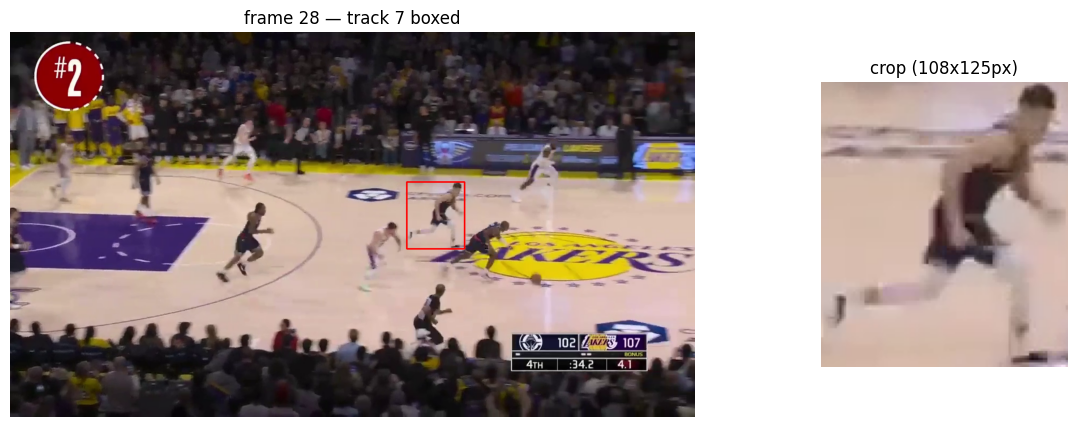

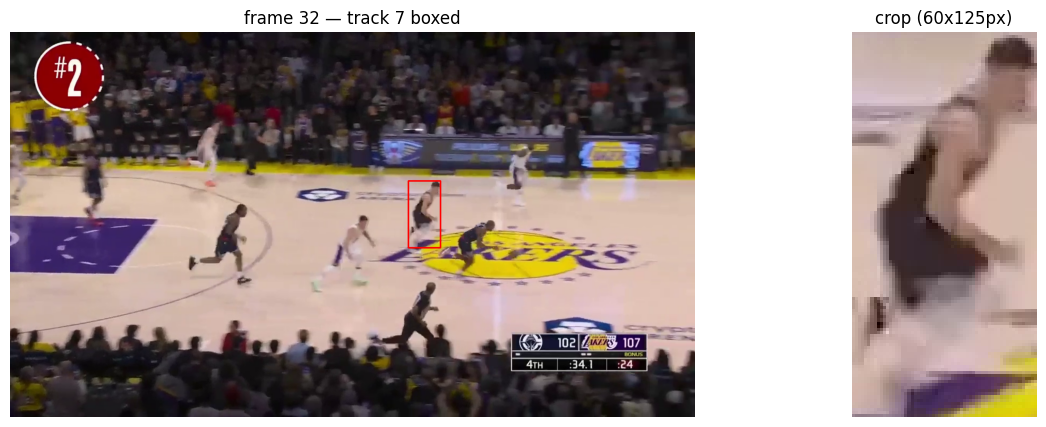

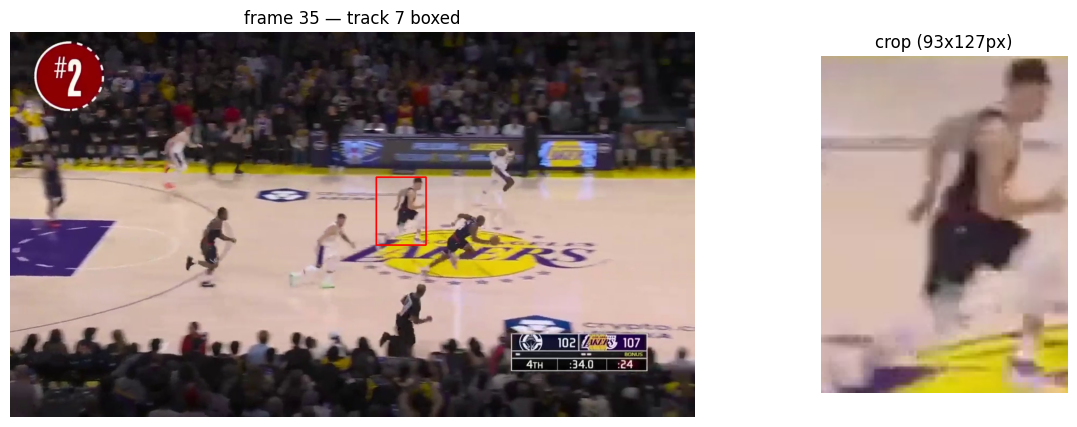

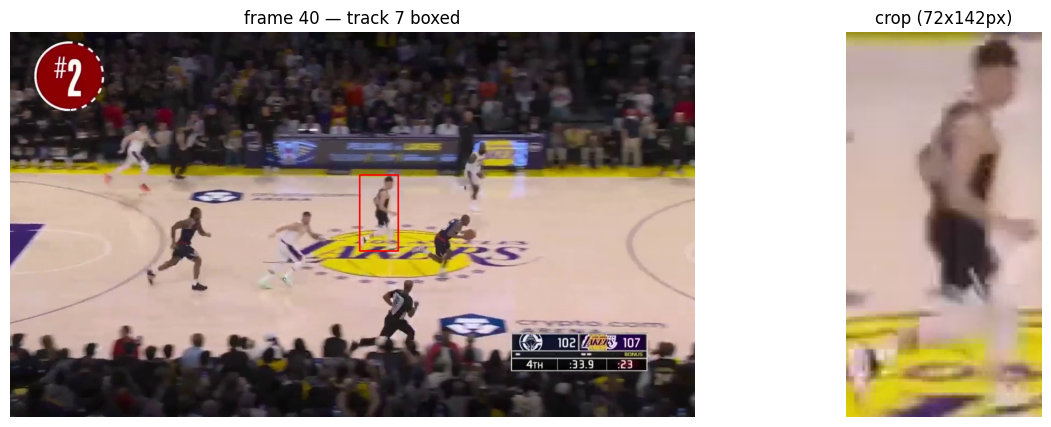

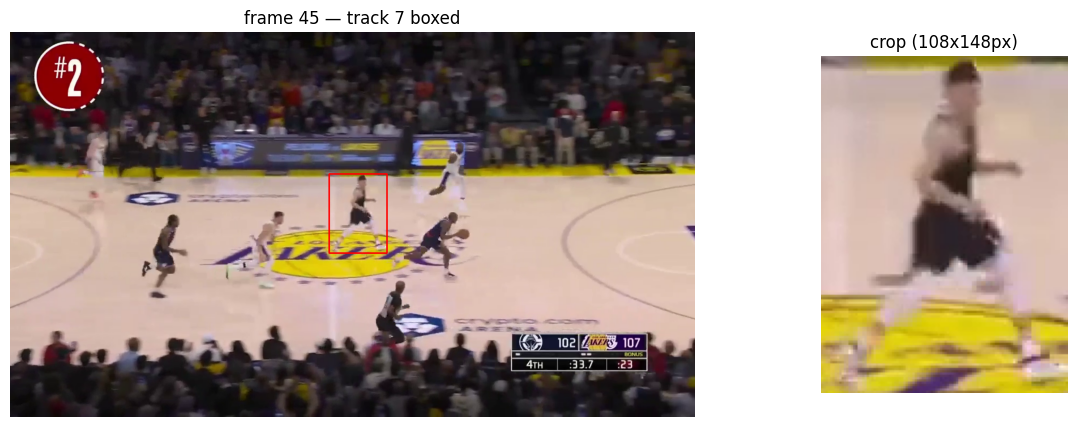

In [13]:
frames = []
cap = cv2.VideoCapture('data/raw/clip_1.mp4')
while True:
    ret, f = cap.read()
    if not ret:
        break
    frames.append(f)
cap.release()

with open('data/processed/clip_1/player_detections.pkl', 'rb') as f:
    tracks = pickle.load(f)

for idx in [28, 32, 35, 40, 45]:
    t = tracks[idx].get(7)
    if t is None:
        print(f'frame {idx}: no track 7')
        continue
    x1, y1, x2, y2 = [int(v) for v in t.bbox]

    full = frames[idx].copy()
    cv2.rectangle(full, (x1, y1), (x2, y2), (0, 0, 255), 2)
    crop = frames[idx][max(0, y1):y2, max(0, x1):x2]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5),
                           gridspec_kw={'width_ratios': [3, 1]})
    ax[0].imshow(cv2.cvtColor(full, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f'frame {idx} — track 7 boxed')
    ax[0].axis('off')
    ax[1].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax[1].set_title(f'crop ({x2-x1}x{y2-y1}px)')
    ax[1].axis('off')
    plt.show()

The crops are around 100 pixels wide, motion blurred, often facing away, and
dominated by the bright centre-court branding; the dark jersey is a small part of
what the classifier reads. That is why the errors carry full confidence: the crop
content, not the decision rule, is the limit, and the crop-fraction comparison below
tests whether tighter cropping recovers it (it does not).

Does a tighter crop read this track better? Full-body and torso-only crops are
compared frame by frame on the labelled frames.

In [14]:
def track_report(crop_fraction, clip='clip_1', player_id=7):
    df = runs[('fashionclip', 'C_nba', crop_fraction)]
    t = df[(df['clip'] == clip) & (df['player_id'] == player_id)].sort_values('frame_idx')
    g = gt[(gt['clip'] == clip) & (gt['player_id'] == player_id)][['frame_idx', 'true_team']]
    m = t.merge(g, on='frame_idx', how='left')
    labelled = m[m['true_team'].notna()].copy()
    labelled['correct'] = labelled['predicted_team'] == labelled['true_team']

    print(f'crop_fraction={crop_fraction}: '
          f'{labelled["correct"].sum()}/{len(labelled)} correct on labelled frames '
          f'({labelled["correct"].mean()*100:.1f}%)')
    print(f'  raw team-1/team-2 split over all {len(m)} frames: '
          f'{(m["predicted_team"]==1).sum()} / {(m["predicted_team"]==2).sum()}')
    print(f'  median confidence correct/wrong: '
          f'{labelled.loc[labelled.correct,"confidence"].median():.3f} / '
          f'{labelled.loc[~labelled.correct,"confidence"].median():.3f}')
    return labelled

print('=== Full-body crop (adopted, 1.0) ===')
full = track_report(1.0)
print()
print('=== Torso-only crop (0.667) ===')
torso = track_report(0.667)

print('\n=== Frame-by-frame comparison on labelled frames ===')
cmp = full[['frame_idx','true_team','predicted_team','confidence']].merge(
    torso[['frame_idx','predicted_team','confidence']],
    on='frame_idx', suffixes=('_full', '_torso'))
print(cmp.to_string(index=False))

=== Full-body crop (adopted, 1.0) ===
crop_fraction=1.0: 8/21 correct on labelled frames (38.1%)
  raw team-1/team-2 split over all 111 frames: 66 / 45
  median confidence correct/wrong: 0.848 / 0.865

=== Torso-only crop (0.667) ===
crop_fraction=0.667: 7/21 correct on labelled frames (33.3%)
  raw team-1/team-2 split over all 111 frames: 70 / 41
  median confidence correct/wrong: 0.808 / 0.779

=== Frame-by-frame comparison on labelled frames ===
 frame_idx  true_team  predicted_team_full  confidence_full  predicted_team_torso  confidence_torso
        15        2.0                    2         0.826788                     2          0.807990
        20        2.0                    2         0.939906                     1          0.555832
        25        2.0                    1         0.510331                     2          0.735421
        30        2.0                    1         0.946823                     1          0.974672
        35        2.0                    1     

## 12. Outcome

The full (arm, policy, fold) grid is written to `data/outputs/sweep_results.csv`; the
shipped copy is `results/team_classification/sweep_results.csv`. The recorded
inference grid it scores ships in `results/team_classification/inference_grid/`.